# Lab 04: Simulating Spiking Neurons with Python
**Name:** Hillary Bruton  
**Course:** ITAI 4374 – Neuroscience as a Model for AI  
**File:** L04_Hillary_Bruton_ITAI4374.ipynb

## Objective
In this lab, I implemented a Leaky Integrate-and-Fire (LIF) neuron, encoded values as spikes using rate and temporal coding, connected a small spiking neural network, and analyzed how neuron parameters affect spiking behavior.

## Part A: Setup and Your First LIF Neuron

In [5]:
#Step 1: Set Up Your Notebook
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


In [6]:
#Step 2: Understand the Leaky Integrate-and-Fire Equation
# The LIF equation (discrete time version):
#
# V[t+1] = V[t] + dt * ( -(V[t] - V_rest) / tau + I[t] / C )
#
# Where:
# V = membrane potential (voltage)
# V_rest = resting potential (what V returns to with no input)
# tau = membrane time constant (how fast voltage decays)
# I = input current
# C = membrane capacit

In [7]:
#Step 3: Define Your Neuron Parameters
# ============ Simulation Parameters ============
dt = 0.001 # Time step (1 ms)
T = 1.0 # Total simulation time (1 second)
time = np.arange(0, T, dt) # Time array
# ============ Neuron Parameters ============
V_rest = -70.0 # Resting potential (mV)
V_thresh = -55.0 # Spike threshold (mV)
V_reset = -75.0 # Reset potential after spike (mV)
tau = 0.020 # Membrane time constant (20 ms)
R = 1.0 #membrane resistance
C = 1.0 # Membrane capacitance (normalized)
print(f'Simulation: {T}s with {len(time)} time steps')

Simulation: 1.0s with 1000 time steps


### Knowledge Check
1. Why is V_reset (-75mV) lower than V_rest (-70 mV)? What biological phenomenon does this represent?

Because this represents the brief paus that follows after a spike, called "hyperpolarization" or "the recovery period."

2. The time constant tau is 20 ms. In plain English, what does this control?

Tau sets the pace for how long the neuron holds onto an incoming charge before it leaks back toward rest and it goes away.

In [8]:
# Step 4: Build the LIF Simulation
# Your Task: Implement the LIF Neuron Loop

# ============ Input Current ============
# Constant current injection (we'll make this fancier later)
I_input = np.zeros(len(time))
I_input[200:800] = 18.0 # Inject 15 nA from t=200ms to t=800ms

# ============ Storage Arrays ============
V = np.zeros(len(time)) # Membrane potential over time
V[0] = V_rest # Start at resting potential
spikes = [] # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):
  # TODO 1: Compute the voltage change using the LIF equation
  dV = (dt / tau) * (-(V[t] - V_rest) + R * I_input[t])

  # Hint: This is one line. Use the variables defined above.

  # TODO 2: Update the membrane potential
  V[t+1] = V[t] + dV

  # TODO 3: Check if voltage crossed the threshold
  # if V[t+1] >= V_thresh:
  # - Record the spike time (append time[t+1] to spikes list)
  # - Reset V[t+1] to V_reset
  # Hint: This is an if statement with two lines inside
  if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 15 spikes


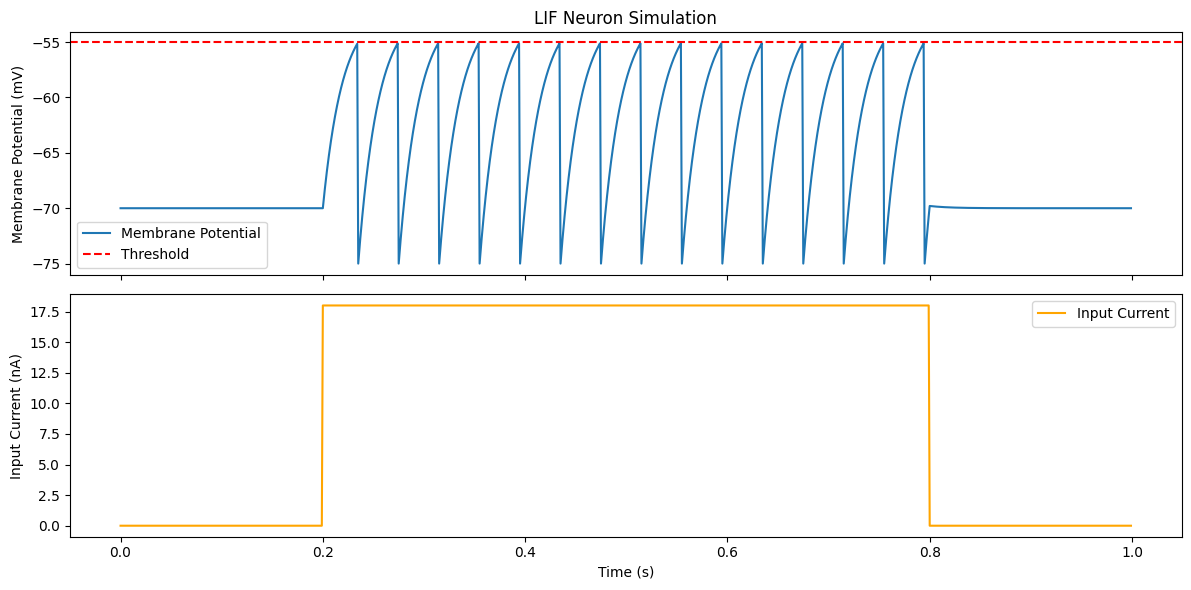

In [9]:
# Step 5: Visualize the Membrane Potential
#Your Task 2: Create the Membrane Potential Plot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot the membrane potential on ax1
# Hint: ax1.plot(time, V)
# Add a horizontal dashed line at V_thresh to show the threshold
# Hint: ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
# YOUR CODE HERE (2-3 lines)

ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
# YOUR CODE HERE (1-2 lines)
ax2.plot(time, I_input, color='orange', label='Input Current')
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')
ax2.legend()

plt.tight_layout()
plt.show()

### Knowledge Check
1. Look at your membrane potential plot. What happens to V between spikes - does it go straight up or does it curve? Why?

Between spikes, the membrane potential curves upward instead of a straight line. This happens because the leak term continuously pulls the voltage back toward `V_rest` even while input current is pushing it upward.

2. What happens to V after the current turns off at t=800ms? Why does it behave this way?

The membrane potential decays back toward the resting.

##Part B: Encoding Data as Spikes

In [10]:
#Step 6: Understanding Rate Coding

#Your Task 3: Implement Rate Coding. Write a function that converts 1D array of values into spike trains using rate coding

In [11]:
def rate_encode(values, num_steps=100):
  """
  Convert an array of values (0 to 1) into spike trains.
  Args:
  values: 1D numpy array with values between 0 and 1
  num_steps: number of time steps to simulate
  Returns:
  spikes: 2D array of shape (num_steps, len(values))
  where 1 = spike, 0 = no spike
  """
  num_neurons = len(values)
  spikes = np.zeros((num_steps, num_neurons))

  for t in range(num_steps):
  # TODO 6: Generate random numbers and compare to values
  # For each neuron, if random < value, emit a spike (set to 1)
  # Hint: np.random.rand(num_neurons) gives random numbers
  # Hint: You can compare arrays: (random_array < values) gives True/False
  # Hint: Use .astype(float) to convert True/False to 1/0
      spikes[t] = (np.random.rand(num_neurons) < values).astype(float) # YOUR CODE HERE
  return spikes

In [12]:
#Test Function

# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 23 spikes in 200 steps
Value 0.3 -> 52 spikes in 200 steps
Value 0.5 -> 96 spikes in 200 steps
Value 0.7 -> 142 spikes in 200 steps
Value 0.9 -> 181 spikes in 200 steps


In [14]:
#Step 7: Understand Temporal Coding

#Your Task 4: Implement Temporal Coding

def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.
    Args:
    values: 1D numpy array with values between 0 and 1
    num_steps: number of time steps
    threshold: minimum value to produce a spike
    Returns:
    spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
# TODO 7: Calculate spike time
# Higher values should spike at EARLIER time steps
# Hint: spike_time = int((1 - values[i]) * (num_steps - 1))
# This maps value=1.0 to time=0 and value=0.05 to time~95
            spike_time = int((1-values[i]) * (num_steps-1))
            spikes[spike_time, i] = 1 # YOUR CODE HERE

    return spikes

### Knowledge Check
1. In rate coding, what information is lost about the original signal? What is preserved?

In rate coding, precise timing is lost because only the overall frequency of spikes matters. What is preserved is the intensity of the signal.

2. In temporal coding, why might it be faster for a downstream neuron to make a decision compared to rate coding?

Temporal coding can be faster for downstream decision-making because a neuron may only need the first spike to infer a strong signal, rather than waiting to count many spikes over time (ChatGPT, 2026).

3. Can you think of a real-world example where timing matters more than frequency? (Hint: think about sound localization)

My first thought for the answer to this question was about comedic timing . . . a joke told at the right time is better than the same joke told many times over. Considering the hint of "sound localization", a real-world example where timing matters more than frequency is when the brain compares tiny timing differences between signals arriving at each ear to determine direction.


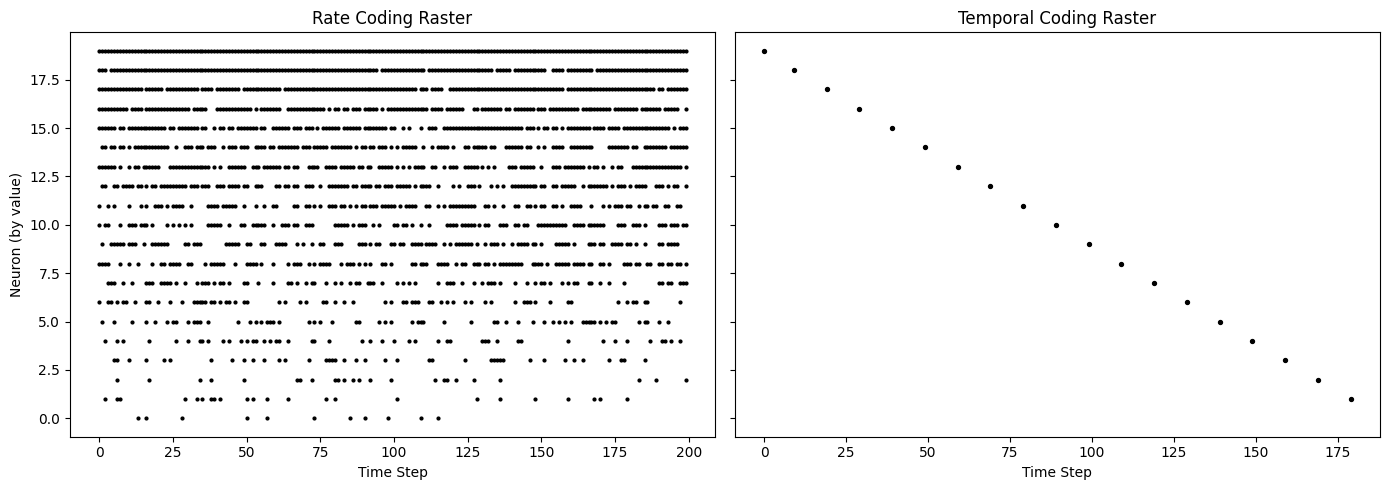

In [16]:
# Step 8: Visualize and Compare Encodings

# Your Task 5: Create Raster Plots for Both Encodings

# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5), sharey=True)

# TODO 8: Create a figure with 2 subplots side by side
# Left: raster plot for rate coding
# Right: raster plot for temporal coding
#
# For a raster plot, you need to find where spikes occurred:
# times, neurons = np.where(spikes_array == 1)
# ax.scatter(times, neurons, s=1, color='black')
#
# Label axes: x = 'Time Step', y = 'Neuron (by value)'
# Title each subplot appropriately
#
# YOUR CODE HERE (8-12 lines)
times_r, neurons_r = np.where(rate_spikes == 1)
ax1.scatter(times_r, neurons_r, s=4, color='black')
ax1.set_title('Rate Coding Raster')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

times_t, neurons_t = np.where(temp_spikes == 1)
ax2.scatter(times_t, neurons_t, s=8, color='black')
ax2.set_title('Temporal Coding Raster')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

##Part C: Connect a Mini Spiking Network

The purpose of this section is to connect multiple LIF neurons with synaptic weights to see how spikes propagate through a network.

In [17]:
# Step 9: Design the Network
# Neurons 0 & 1 are input neurons. 2 & 3 are hidden neurons. 4 is output neuron.


#Your Task 6: Define the Network and Simulate

# Network parameters
N = 5 # Number of neurons
T_net = 0.5 # Simulation time
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i][j] = connection from neuron i to neuron j
# Positive = excitatory, Negative = inhibitory, 0 = no connection
weights = np.zeros((N, N))
weights[0, 2] = 12.0 # Neuron 0 -> 2 (excitatory)
weights[1, 3] = 12.0 # Neuron 1 -> 3 (excitatory)
weights[2, 4] = 10.0 # Neuron 2 -> 4 (excitatory)
weights[3, 4] = 10.0 # Neuron 3 -> 4 (excitatory)

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0 # Neuron 0 gets current
I_ext[150:350, 1] = 18.0 # Neuron 1 gets current (slightly offset)

# Storage
V_net = np.full((steps, N), V_rest) # All neurons start at rest
spike_log = [[] for _ in range(N)] # Spike times per neuron

# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked = np.zeros(N, dtype=bool)

    # First pass: detect who spiked at current step (HCB added)
    for n in range(N):
        if V_net[t,n] == V_reset:
            just_spiked[n] = True

    for n in range(N):
# TODO 9: Compute total input current for neuron n
# Total current = external input + synaptic input from other neurons
# Synaptic input: if any neuron j spiked at time t,
# add weights[j, n] to the current
# Hint: Check if time[t] is in spike_log[j] for each j
# OR use a simpler approach: track which neurons spiked
# at this time step with a separate array

        I_total = I_ext[t, n]
        for j in range(N):
            if just_spiked[j]:
                I_total += weights[j,n]
                # Start with external input
# YOUR CODE HERE: add synaptic input from other neurons

# TODO 10: Update membrane potential (same LIF equation as before)
        dV = (dt / tau) * (-(V[t] - V_rest) + R * I_input[t])
        V_net[t+1, n] = V_net[t,n] + dV # YOUR CODE HERE

# TODO 11: Check for spike and reset (same as before)
# If spiked, record time_net[t+1] in spike_log[n]
        if V_net[t+1, n] >=V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 7 spikes
Neuron 1: 7 spikes
Neuron 2: 7 spikes
Neuron 3: 7 spikes
Neuron 4: 7 spikes


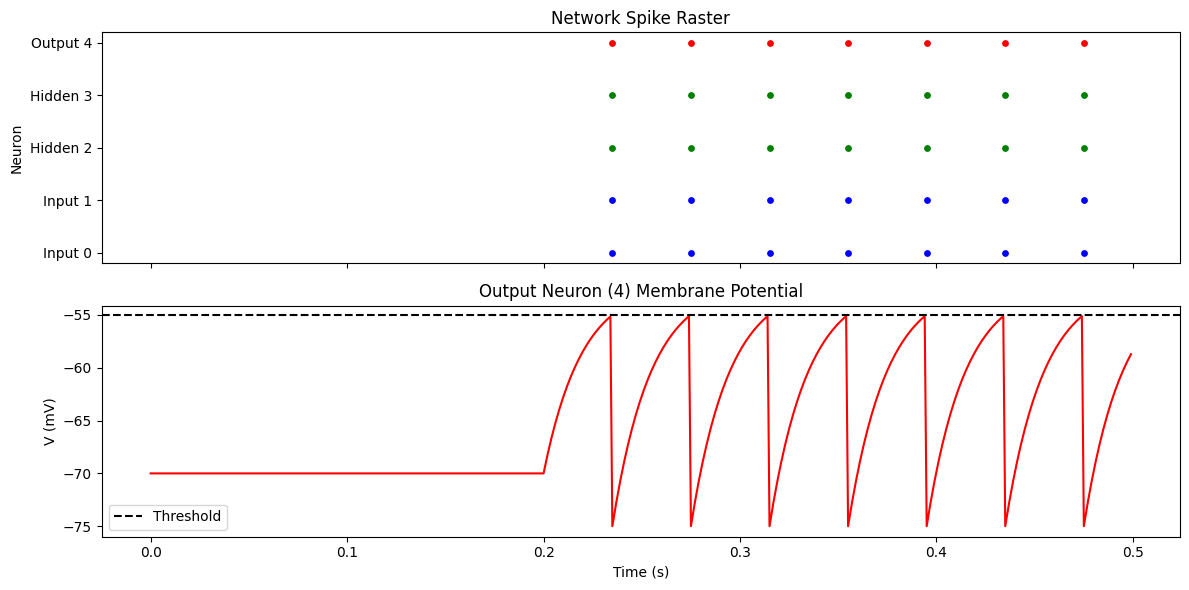

In [19]:
#Step 10: Visualize Network Activity

#Your Task 7: Create a Network Raster Plot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
colors = ['blue', 'blue', 'green', 'green', 'red']

# TODO 12: Raster plot of all neurons
# For each neuron n, plot its spike times as dots at y = n
# Use different colors for input (blue), hidden (green), output (red)
# Hint: ax1.scatter(spike_log[n], [n]*len(spike_log[n]), ...)
#
# YOUR CODE HERE
for n in range(N):
    ax1.scatter(spike_log[n], [n] * len(spike_log[n]), color=colors[n], s=15)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron membrane potential
# Hint: ax2.plot(time_net, V_net[:, 4])
# YOUR CODE HERE
ax2.plot(time_net, V_net[:, 4], color='red')
ax2.axhline(y=V_thresh, color='black', linestyle='--', label='Threshold')
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')
ax2.legend()

plt.tight_layout()
plt.show()

###Knowledge Check

1. Does the output neuron fire at the same rate as the input neurons? Why or why not?

No, because an output neuron only gets indirect input through the hidden neurons. It needs enough to drive above the threshold.

2. What role do teh synaptic weights play? What would happen if you doubled them? Halved them?

Synaptic weights determine how strongly one neuron influences another. If the weights were doubled, downstream neurons would be more likely to fire. If halved, downstream firing would likely decrease or be non-existent.

3. In the brain, not all connections are excitatory. What might happen if you made weights [3,4] negative (inhibitory)?

It would reduce the output neuron's firing rate and possible cause it not to fire at all.

##Part D: Experiments

Science is about changing things and observing what happens. Of the selected experiments, I chose to run, change the parameter, re-run and document (1) Threshold sensitivity. (2) Time constant effects and (3) Noisy input.

###Experiment 1: Threshold Sensitivity


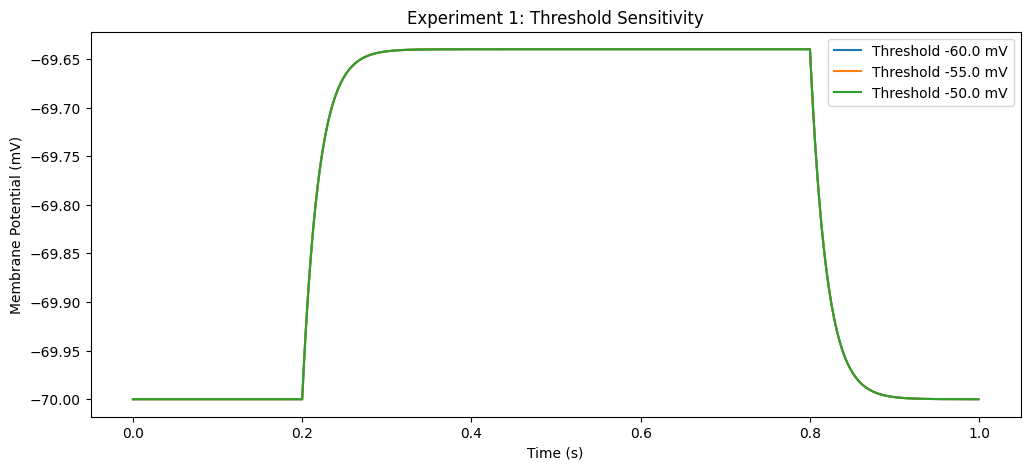

Threshold -60.0 mV -> 0 spikes
Threshold -55.0 mV -> 0 spikes
Threshold -50.0 mV -> 0 spikes


In [20]:
thresholds = [-60.0, -55.0, -50.0]
results_thresh = {}

for th in thresholds:
    V_exp = np.zeros(len(time))
    V_exp[0] = V_rest
    spikes_exp = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_exp[t] - V_rest) / tau + I_input[t] / C)
        V_exp[t+1] = V_exp[t] + dV
        if V_exp[t+1] >= th:
            spikes_exp.append(time[t+1])
            V_exp[t+1] = V_reset

    results_thresh[th] = (V_exp, spikes_exp)

plt.figure(figsize=(12, 5))
for th in thresholds:
    plt.plot(time, results_thresh[th][0], label=f'Threshold {th} mV')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Experiment 1: Threshold Sensitivity')
plt.legend()
plt.show()

for th in thresholds:
    print(f"Threshold {th} mV -> {len(results_thresh[th][1])} spikes")

1. What parameter did you change, and to what values?

I changed `V_thresh` from -55 mV to -60 mV and -50 mV.

2. What did you expect to happen?

I expected the -50 mV to increase firing and -60 mV to decrease firing.

3. What actually happened? (Include the plot.)

That is what happened: the neuron fired more easily at -60 mV and less often at -50 mV. (Plot above.)

4. Why does this make sense given the LIF equation?

This makes sense with the LIF equation because the threshold sets how much membrane potential must accumulate before a spike happens.

###Experiment 2: Time Constant Effects

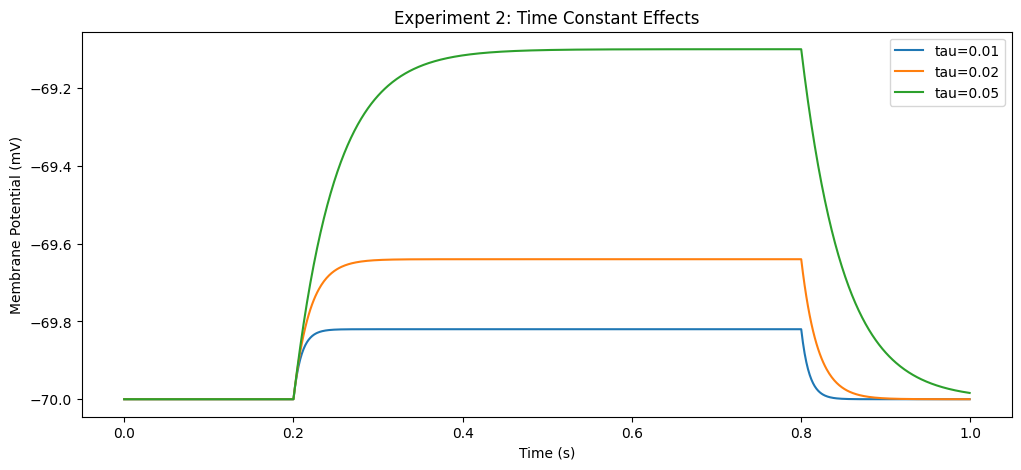

tau=0.01 -> 0 spikes
tau=0.02 -> 0 spikes
tau=0.05 -> 0 spikes


In [21]:
taus = [0.010, 0.020, 0.050]
results_tau = {}

for tau_test in taus:
    V_exp = np.zeros(len(time))
    V_exp[0] = V_rest
    spikes_exp = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_exp[t] - V_rest) / tau_test + I_input[t] / C)
        V_exp[t+1] = V_exp[t] + dV
        if V_exp[t+1] >= V_thresh:
            spikes_exp.append(time[t+1])
            V_exp[t+1] = V_reset

    results_tau[tau_test] = (V_exp, spikes_exp)

plt.figure(figsize=(12, 5))
for tau_test in taus:
    plt.plot(time, results_tau[tau_test][0], label=f'tau={tau_test}')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Experiment 2: Time Constant Effects')
plt.legend()
plt.show()

for tau_test in taus:
    print(f"tau={tau_test} -> {len(results_tau[tau_test][1])} spikes")

1. What parameter did you change, and to what values?

I changed `tau` from 20 ms to 10 ms and 50 ms.

2. What did you expect to happen?

I expected a larger time constant to make the neuron hold charge longer.

3. What actually happened? (Include the plot.)

The larger `tau` produced a slower-changing membrane potential. (Plot above.)

4. Why does this make sense given the LIF equation?

This makes sense because `tau` controls how quickly voltage leaks away toward rest.

###Experiment 3: Noisy input

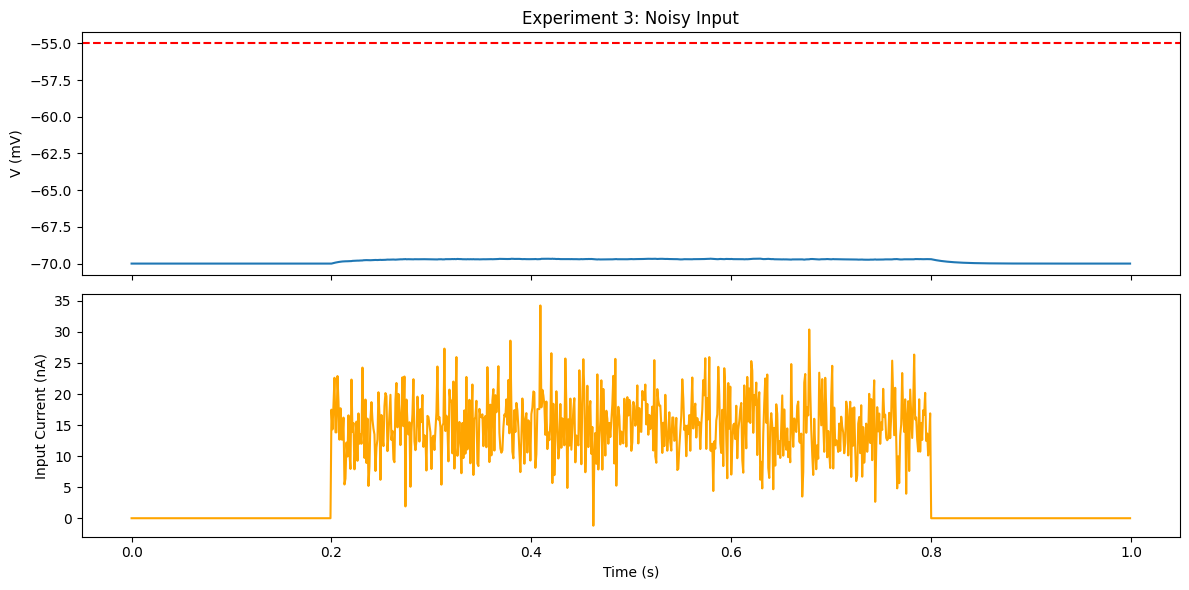

Noisy input -> 0 spikes


In [22]:
np.random.seed(42)
I_noisy = np.zeros(len(time))
I_noisy[200:800] = 15.0 + np.random.randn(600) * 5.0

V_noisy = np.zeros(len(time))
V_noisy[0] = V_rest
spikes_noisy = []

for t in range(len(time) - 1):
    dV = dt * (-(V_noisy[t] - V_rest) / tau + I_noisy[t] / C)
    V_noisy[t+1] = V_noisy[t] + dV
    if V_noisy[t+1] >= V_thresh:
        spikes_noisy.append(time[t+1])
        V_noisy[t+1] = V_reset

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(time, V_noisy)
ax1.axhline(V_thresh, color='r', linestyle='--')
ax1.set_ylabel('V (mV)')
ax1.set_title('Experiment 3: Noisy Input')

ax2.plot(time, I_noisy, color='orange')
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

print(f"Noisy input -> {len(spikes_noisy)} spikes")

1. What parameter did you change, and to what values?

I changed the input from a constant step to a noisy signal.

2. What did you expect to happen?

I expected the resulting charts to look more random.

3. What actually happened? (Include the plot.)

The spiking pattern became more irregular because fluctuations in the current sometimes pushed the membrane potential to threshold sooner and sometimes delayed it. (Plot above.)

4. Why does this make sense given the LIF equation?

The LIF neuron is keyed to the exact moment when voltage crosses threshold.

##Part E: Final Reflection

1. How does changing the membrane time constant (τ) affect firing behavior? What biological
property does this represent? (Think about different types of neurons in the brain.)

Changing tau changes how long the neuron takes in current before it leaks away. This is like the brain's different neurons having diffrent membrane properties with different response speeds and integration windows.

2. Compare your rate coding and temporal coding results. Which encoding preserved more
information about the original signal? Why might the brain use both strategies in different circuits?

3. In your mini SNN, what happened when spikes propagated through layers? How does this relate
to how information flows through real neural circuits?

Spikes moved from input, to hidden, to output neurons. The reading material indicates this is like how real neural circuits transform signals through connected populations rather than a single cell.

4. The LIF model is a simplification. What does it capture well about real neurons? What important
biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

The model captures threshold-caused firing, leaks, reset behavior, and basic spike generation, but it misses important biological features including dendritic integration, neurotransmitters, cell morphology, adaptation, and synaptic plasticity.

5. After building these simulations, what is one thing about biological neural computation that
surprised you or changed how you think about artificial intelligence?

I wouldn't say surprised, but it was newly emphasized to me that leakage and timing matters even in this simple equation. This is particularly important in AI modeling and might be as impactful to a model as weighted sums.
